In [1]:
from IPython.display import Markdown as md
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

from vllm import LLM, SamplingParams

INFO 11-23 13:07:50 [__init__.py:216] Automatically detected platform cuda.


In [2]:
root_path = "/home/stefan/ioai-prep/kits/rezi"

seed = 42

# LLM Inference

In [3]:
llm = LLM(
    model="openai/gpt-oss-20b",
    gpu_memory_utilization=0.9,
    max_model_len=4096,
    max_num_seqs=30,
)

INFO 11-23 13:07:54 [utils.py:233] non-default args: {'max_model_len': 4096, 'max_num_seqs': 30, 'disable_log_stats': True, 'model': 'openai/gpt-oss-20b'}
INFO 11-23 13:07:55 [model.py:547] Resolved architecture: GptOssForCausalLM


`torch_dtype` is deprecated! Use `dtype` instead!


Parse safetensors files:   0%|          | 0/3 [00:00<?, ?it/s]

INFO 11-23 13:07:56 [model.py:1510] Using max model len 4096
INFO 11-23 13:07:58 [scheduler.py:205] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 11-23 13:07:58 [config.py:271] Overriding max cuda graph capture size to 992 for performance.
(EngineCore_DP0 pid=45467) INFO 11-23 13:08:00 [core.py:644] Waiting for init message from front-end.
(EngineCore_DP0 pid=45467) INFO 11-23 13:08:00 [core.py:77] Initializing a V1 LLM engine (v0.11.0) with config: model='openai/gpt-oss-20b', speculative_config=None, tokenizer='openai/gpt-oss-20b', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=mxfp4, enforce_eager=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto'

Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]


(EngineCore_DP0 pid=45467) INFO 11-23 13:08:12 [default_loader.py:267] Loading weights took 9.00 seconds
(EngineCore_DP0 pid=45467) WARNING 11-23 13:08:12 [marlin_utils_fp4.py:196] Your GPU does not have native support for FP4 computation but FP4 quantization is being used. Weight-only FP4 compression will be used leveraging the Marlin kernel. This may degrade performance for compute-heavy workloads.
(EngineCore_DP0 pid=45467) INFO 11-23 13:08:13 [gpu_model_runner.py:2653] Model loading took 13.7164 GiB and 10.802893 seconds
(EngineCore_DP0 pid=45467) INFO 11-23 13:08:17 [backends.py:548] Using cache directory: /home/stefan/.cache/vllm/torch_compile_cache/5ef53a98b7/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=45467) INFO 11-23 13:08:17 [backends.py:559] Dynamo bytecode transform time: 3.95 s
(EngineCore_DP0 pid=45467) INFO 11-23 13:08:19 [backends.py:164] Directly load the compiled graph(s) for dynamic shape from the cache, took 1.327 s
(EngineCore_DP0 pid=45467) INF

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 81/81 [00:06<00:00, 12.69it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 6/6 [00:00<00:00, 15.59it/s]


(EngineCore_DP0 pid=45467) INFO 11-23 13:08:34 [gpu_model_runner.py:3480] Graph capturing finished in 7 secs, took 0.69 GiB
(EngineCore_DP0 pid=45467) INFO 11-23 13:08:34 [core.py:210] init engine (profile, create kv cache, warmup model) took 21.01 seconds
INFO 11-23 13:08:36 [llm.py:306] Supported_tasks: ['generate']


# Data

In [4]:
test_df = pd.read_csv(f"{root_path}/test.csv")
test_df.head()

,SampleID,Question,Option0,Option1,Option2,Option3
0,b64a9cd7-d076-4c55-8be1-f9c44fece6cc,A 29 yrs old woman with a pregnancy of 17 week...,No test is required now as her age is below 35...,Ultra sound at this point of time will definit...,Amniotic fluid samples plus chromosomal analys...,blood screening at this point of time will cle...
1,17360c6c-2c98-4fe2-aa85-487dcf4678df,Concentration of tropicamide:,0.01,0.02,0.03,0.04
2,ce49098b-cc48-4168-859e-936e3e0c7459,Which of the following are not a branch of ext...,Sphenopalatine aery,Anterior ethmoidal aery,Greater palatine aery,Septal branch of superior labial aery
3,18d5c4a1-cb81-41a8-9bfc-b6f7dec431d2,Diagnosis of the following ECG-,Ventricular bigeminy,Electrical alternans,P pulmonale,Left ventricular failure
4,384a9281-2ee1-480b-a7d8-fd3ef49558e5,27.\tThe lateral spread of dental caries is fa...,Enamel spindles,Dentinoenamel junction,Enamel lamellae,Striae of Retzius


In [5]:
def build_prompt(row):
    # Few-shot plus main question
    few_shots = """
Example 1:
Question:
```
A 30-year-old man presents with fever, night sweats, and a painless enlarged cervical lymph node. Histology shows Reed-Sternberg cells.
```

Options:
1. Non-Hodgkin lymphoma
2. Hodgkin lymphoma
3. Infectious mononucleosis
4. Tuberculosis

Answer: 2

Example 2:
Question:
```
A 5-year-old boy presents with a barking cough in winter. Auscultation reveals inspiratory stridor.
```
Options:
1. Bronchiolitis
2. Epiglottitis
3. Laryngitis (croup)
4. Pneumonia

Answer: 3
""".strip()

    current = f"""
Question:
```
{row["Question"]}
```

Options:
1. {row["Option0"]}
2. {row["Option1"]}
3. {row["Option2"]}
4. {row["Option3"]}

""".strip()

    return few_shots + "\n\n" + current


def apply_template(row):
    prompt = llm.get_tokenizer().apply_chat_template(
        conversation=[
            {
                "role": "system",
                "content": (
                    "You are a highly knowledgeable medical expert. "
                    "Your task is to solve multiple-choice questions from the Medical Residency Exam. "
                    "Answer based on medical reasoning and established facts. "
                    "Respond strictly with a single number from 1 to 4, with no extra text or explanation."
                ),
            },
            {
                "role": "user",
                "content": row["Prompt"],
            },
        ],
        tokenize=False,
        reasoning_effort="low",
    )
    return prompt


test_df["Prompt"] = test_df.apply(build_prompt, axis=1)
test_df["Convo"] = test_df.apply(apply_template, axis=1)

count    2816.000000
mean     1300.529119
std        82.617012
min      1168.000000
25%      1246.000000
50%      1278.000000
75%      1333.000000
max      1921.000000
Name: Convo, dtype: float64


<Axes: >

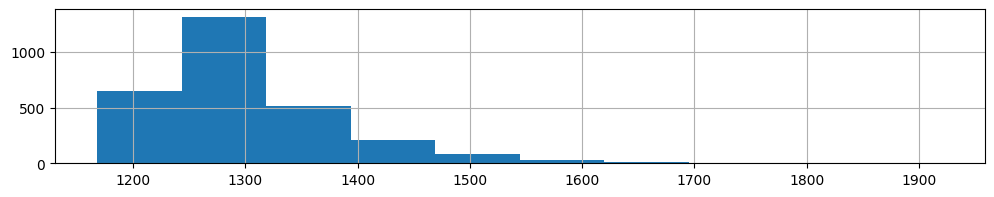

In [6]:
print(test_df["Convo"].apply(len).describe())

plt.figure(figsize=(12, 2))
test_df["Convo"].apply(len).hist()

In [7]:
test_df.iloc[0]["Convo"]

'<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.\nKnowledge cutoff: 2024-06\nCurrent date: 2025-11-23\n\nReasoning: low\n\n# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>developer<|message|># Instructions\n\nYou are a highly knowledgeable medical expert. Your task is to solve multiple-choice questions from the Medical Residency Exam. Answer based on medical reasoning and established facts. Respond strictly with a single number from 1 to 4, with no extra text or explanation.\n\n<|end|><|start|>user<|message|>Example 1:\nQuestion:\n```\nA 30-year-old man presents with fever, night sweats, and a painless enlarged cervical lymph node. Histology shows Reed-Sternberg cells.\n```\n\nOptions:\n1. Non-Hodgkin lymphoma\n2. Hodgkin lymphoma\n3. Infectious mononucleosis\n4. Tuberculosis\n\nAnswer: 2\n\nExample 2:\nQuestion:\n```\nA 5-year-old boy presents with a barking cough in winter. Auscultation rev

In [8]:
sample_prompt = test_df.iloc[0]["Convo"]
md(test_df.iloc[0]["Prompt"])

Example 1:
Question:
```
A 30-year-old man presents with fever, night sweats, and a painless enlarged cervical lymph node. Histology shows Reed-Sternberg cells.
```

Options:
1. Non-Hodgkin lymphoma
2. Hodgkin lymphoma
3. Infectious mononucleosis
4. Tuberculosis

Answer: 2

Example 2:
Question:
```
A 5-year-old boy presents with a barking cough in winter. Auscultation reveals inspiratory stridor.
```
Options:
1. Bronchiolitis
2. Epiglottitis
3. Laryngitis (croup)
4. Pneumonia

Answer: 3

Question:
```
A 29 yrs old woman with a pregnancy of 17 week has a 10 years old boy with down syndrome. She does not want another down syndrome kid; best advice to her is
```

Options:
1. No test is required now as her age is below 35 years
2. Ultra sound at this point of time will definitely tell her that next baby will be down syndromic or not
3. Amniotic fluid samples plus chromosomal analysis will definitely tell her that next baby will be down syndromic or not
4. blood screening at this point of time will clear the exact picture

# Submission

In [9]:
sampling_params = SamplingParams(temperature=1.0, top_p=1.0, top_k=0, max_tokens=2000)

In [10]:
output = llm.generate(sample_prompt, sampling_params)[0]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

In [11]:
md(output.outputs[0].text)

analysisWe need answer. She is 29, has a child with Down. She wants counseling. Best advice: Amniocentesis at 16-20 weeks for karyotype. So option3.final3

In [12]:
prompts = test_df["Convo"].tolist()

# generate in batches
outputs = []
for i, out in enumerate(
    tqdm(llm.generate(prompts, sampling_params), total=len(prompts))
):
    outputs.append(out)

Adding requests:   0%|          | 0/2816 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/2816 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s…

100%|██████████| 2816/2816 [00:00<00:00, 2647055.15it/s]


In [13]:
def extract_digit(text: str) -> int:
    ch = text.strip()[-1]
    if ch in {"1", "2", "3", "4"}:
        return int(ch)
    return 5  # fallback


test_df["PredictedAnswer"] = [extract_digit(o.outputs[0].text) for o in outputs]

<Axes: >

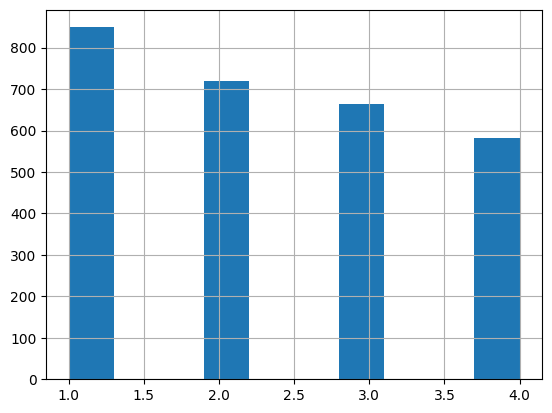

In [14]:
test_df["PredictedAnswer"].hist()

In [15]:
test_df["PredictedAnswer"] = test_df["PredictedAnswer"].replace(5, 2) - 1

In [16]:
submission = test_df[["SampleID", "PredictedAnswer"]].rename(
    columns={"SampleID": "DatapointID"}
)
submission.to_csv(f"{root_path}/submission.csv", index=False)

In [17]:
submission.head()

,DatapointID,PredictedAnswer
0,b64a9cd7-d076-4c55-8be1-f9c44fece6cc,2
1,17360c6c-2c98-4fe2-aa85-487dcf4678df,0
2,ce49098b-cc48-4168-859e-936e3e0c7459,1
3,18d5c4a1-cb81-41a8-9bfc-b6f7dec431d2,1
4,384a9281-2ee1-480b-a7d8-fd3ef49558e5,0
